In [169]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [170]:
data_path = os.path.expanduser('~/DDM_Project/Proposed_method/region_activity_with_rich_stim.npz')
data = np.load(data_path, allow_pickle=True)

Y_raw = data['Y']                        # (490816, 4) - firing rates for [VISal, VISl, VISp, VISpm]
U_raw = data['U_rich']                   # (490816, 15) - rich stimulus features
t_raw = data['time_bins']                # (490816,)   - time in seconds
regions = list(data['regions'])          # ['VISal', 'VISl', 'VISp', 'VISpm']
feature_names = list(data['feature_names'])  # 15 rich feature names
from scipy.ndimage import gaussian_filter1d

# Behavioral
running_raw = data['running_speed']
pupil_raw = data['pupil_width']

# ----------------------------
# Split raw data into train/val/test = 70/15/15
# ----------------------------
n_total = len(t_raw)
train_end = int(0.7 * n_total)
val_end = int(0.85 * n_total)

Y_raw_train, Y_raw_val, Y_raw_test = Y_raw[:train_end, :], Y_raw[train_end:val_end, :], Y_raw[val_end:, :]
U_raw_train, U_raw_val, U_raw_test = U_raw[:train_end, :], U_raw[train_end:val_end, :], U_raw[val_end:, :]
t_raw_train, t_raw_val, t_raw_test = t_raw[:train_end], t_raw[train_end:val_end], t_raw[val_end:]
running_raw_train, running_raw_val, running_raw_test = running_raw[:train_end], running_raw[train_end:val_end], running_raw[val_end:]
pupil_raw_train, pupil_raw_val, pupil_raw_test = pupil_raw[:train_end], pupil_raw[train_end:val_end], pupil_raw[val_end:]

# ----------------------------
# Downsample each split separately
# ----------------------------
ds = 40

n_trim_train = (len(t_raw_train) // ds) * ds
n_trim_val = (len(t_raw_val) // ds) * ds
n_trim_test = (len(t_raw_test) // ds) * ds

Y_ds_train = Y_raw_train[:n_trim_train].reshape(-1, ds, 4).mean(axis=1)
Y_ds_val = Y_raw_val[:n_trim_val].reshape(-1, ds, 4).mean(axis=1)
Y_ds_test  = Y_raw_test[:n_trim_test].reshape(-1, ds, 4).mean(axis=1)

U_ds_train = U_raw_train[:n_trim_train].reshape(-1, ds, 15).mean(axis=1)
U_ds_val = U_raw_val[:n_trim_val].reshape(-1, ds, 15).mean(axis=1)
U_ds_test  = U_raw_test[:n_trim_test].reshape(-1, ds, 15).mean(axis=1)

t_ds_train = t_raw_train[:n_trim_train].reshape(-1, ds).mean(axis=1)
t_ds_val = t_raw_val[:n_trim_val].reshape(-1, ds).mean(axis=1)
t_ds_test  = t_raw_test[:n_trim_test].reshape(-1, ds).mean(axis=1)

running_ds_train = running_raw_train[:n_trim_train].reshape(-1, ds).mean(axis=1)
running_ds_val = running_raw_val[:n_trim_val].reshape(-1, ds).mean(axis=1)
running_ds_test  = running_raw_test[:n_trim_test].reshape(-1, ds).mean(axis=1)

pupil_ds_train = pupil_raw_train[:n_trim_train].reshape(-1, ds).mean(axis=1)
pupil_ds_val = pupil_raw_val[:n_trim_val].reshape(-1, ds).mean(axis=1)
pupil_ds_test  = pupil_raw_test[:n_trim_test].reshape(-1, ds).mean(axis=1)

# # ----------------------------
# # Gaussian smoothing (applied separately to each split)
# # sigma is measured in downsampled timesteps
# # ----------------------------
# gaussian_sigma = 2.0

# Y_ds_train = gaussian_filter1d(Y_ds_train, sigma=gaussian_sigma, axis=0, mode='nearest')
# Y_ds_val = gaussian_filter1d(Y_ds_val, sigma=gaussian_sigma, axis=0, mode='nearest')
# Y_ds_test = gaussian_filter1d(Y_ds_test, sigma=gaussian_sigma, axis=0, mode='nearest')

# U_ds_train = gaussian_filter1d(U_ds_train, sigma=gaussian_sigma, axis=0, mode='nearest')
# U_ds_val = gaussian_filter1d(U_ds_val, sigma=gaussian_sigma, axis=0, mode='nearest')
# U_ds_test = gaussian_filter1d(U_ds_test, sigma=gaussian_sigma, axis=0, mode='nearest')

# running_ds_train = gaussian_filter1d(running_ds_train, sigma=gaussian_sigma, mode='nearest')
# running_ds_val = gaussian_filter1d(running_ds_val, sigma=gaussian_sigma, mode='nearest')
# running_ds_test = gaussian_filter1d(running_ds_test, sigma=gaussian_sigma, mode='nearest')

# pupil_ds_train = gaussian_filter1d(pupil_ds_train, sigma=gaussian_sigma, mode='nearest')
# pupil_ds_val = gaussian_filter1d(pupil_ds_val, sigma=gaussian_sigma, mode='nearest')
# pupil_ds_test = gaussian_filter1d(pupil_ds_test, sigma=gaussian_sigma, mode='nearest')

# ----------------------------
# Clip outliers
# ----------------------------
running_ds_train = np.clip(running_ds_train, 0, None)
running_ds_val = np.clip(running_ds_val, 0, None)
running_ds_test  = np.clip(running_ds_test, 0, None)

pupil_clip_train = np.percentile(pupil_ds_train, 99)
pupil_ds_train = np.clip(pupil_ds_train, 0, pupil_clip_train)
pupil_ds_val = np.clip(pupil_ds_val, 0, pupil_clip_train)
pupil_ds_test  = np.clip(pupil_ds_test, 0, pupil_clip_train)

# ----------------------------
# Normalize time to [0, 1] using train range
# ----------------------------
t_min, t_max = t_ds_train.min(), t_ds_train.max()
t_norm_train = (t_ds_train - t_min) / (t_max - t_min)
t_norm_val = (t_ds_val - t_min) / (t_max - t_min)
t_norm_test  = (t_ds_test - t_min) / (t_max - t_min)

# ----------------------------
# Standardize stimulus and behavior using train fit only
# ----------------------------
from sklearn.preprocessing import StandardScaler

u_scaler = StandardScaler()
U_norm_train = u_scaler.fit_transform(U_ds_train)
U_norm_val = u_scaler.transform(U_ds_val)
U_norm_test  = u_scaler.transform(U_ds_test)

beh_scaler = StandardScaler()
beh_train = np.column_stack([running_ds_train, pupil_ds_train])
beh_val = np.column_stack([running_ds_val, pupil_ds_val])
beh_test  = np.column_stack([running_ds_test, pupil_ds_test])
beh_norm_train = beh_scaler.fit_transform(beh_train)
beh_norm_val = beh_scaler.transform(beh_val)
beh_norm_test  = beh_scaler.transform(beh_test)

# ----------------------------
# Min-max normalize Y using train range only
# ----------------------------
Y_min = Y_ds_train.min(axis=0, keepdims=True)
Y_max = Y_ds_train.max(axis=0, keepdims=True)

Y_norm_train = (Y_ds_train - Y_min) / (Y_max - Y_min + 1e-10)
Y_norm_val = (Y_ds_val - Y_min) / (Y_max - Y_min + 1e-10)
Y_norm_test  = (Y_ds_test - Y_min) / (Y_max - Y_min + 1e-10)

# ----------------------------
# Convert to tensors
# ----------------------------
t_tensor_train = torch.tensor(t_norm_train, dtype=torch.float32, device=device).unsqueeze(1)
t_tensor_val = torch.tensor(t_norm_val, dtype=torch.float32, device=device).unsqueeze(1)
t_tensor_test  = torch.tensor(t_norm_test, dtype=torch.float32, device=device).unsqueeze(1)

Y_tensor_train = torch.tensor(Y_norm_train, dtype=torch.float32, device=device)
Y_tensor_val = torch.tensor(Y_norm_val, dtype=torch.float32, device=device)
Y_tensor_test  = torch.tensor(Y_norm_test, dtype=torch.float32, device=device)

U_tensor_train = torch.tensor(U_norm_train, dtype=torch.float32, device=device)
U_tensor_val = torch.tensor(U_norm_val, dtype=torch.float32, device=device)
U_tensor_test  = torch.tensor(U_norm_test, dtype=torch.float32, device=device)

beh_tensor_train = torch.tensor(beh_norm_train, dtype=torch.float32, device=device)
beh_tensor_val = torch.tensor(beh_norm_val, dtype=torch.float32, device=device)
beh_tensor_test  = torch.tensor(beh_norm_test, dtype=torch.float32, device=device)

print(f"Train: {Y_ds_train.shape[0]} timesteps")
print(f"Val:   {Y_ds_val.shape[0]} timesteps")
print(f"Test:  {Y_ds_test.shape[0]} timesteps")
print(f"Regions: {regions}")
print(f"Train tensors: t={t_tensor_train.shape}, Y={Y_tensor_train.shape}, U={U_tensor_train.shape}, beh={beh_tensor_train.shape}")
print(f"Val tensors:   t={t_tensor_val.shape}, Y={Y_tensor_val.shape}, U={U_tensor_val.shape}, beh={beh_tensor_val.shape}")
print(f"Test tensors:  t={t_tensor_test.shape}, Y={Y_tensor_test.shape}, U={U_tensor_test.shape}, beh={beh_tensor_test.shape}")



Train: 8589 timesteps
Val:   1840 timesteps
Test:  1840 timesteps
Regions: ['VISal', 'VISl', 'VISp', 'VISpm']
Train tensors: t=torch.Size([8589, 1]), Y=torch.Size([8589, 4]), U=torch.Size([8589, 15]), beh=torch.Size([8589, 2])
Val tensors:   t=torch.Size([1840, 1]), Y=torch.Size([1840, 4]), U=torch.Size([1840, 15]), beh=torch.Size([1840, 2])
Test tensors:  t=torch.Size([1840, 1]), Y=torch.Size([1840, 4]), U=torch.Size([1840, 15]), beh=torch.Size([1840, 2])


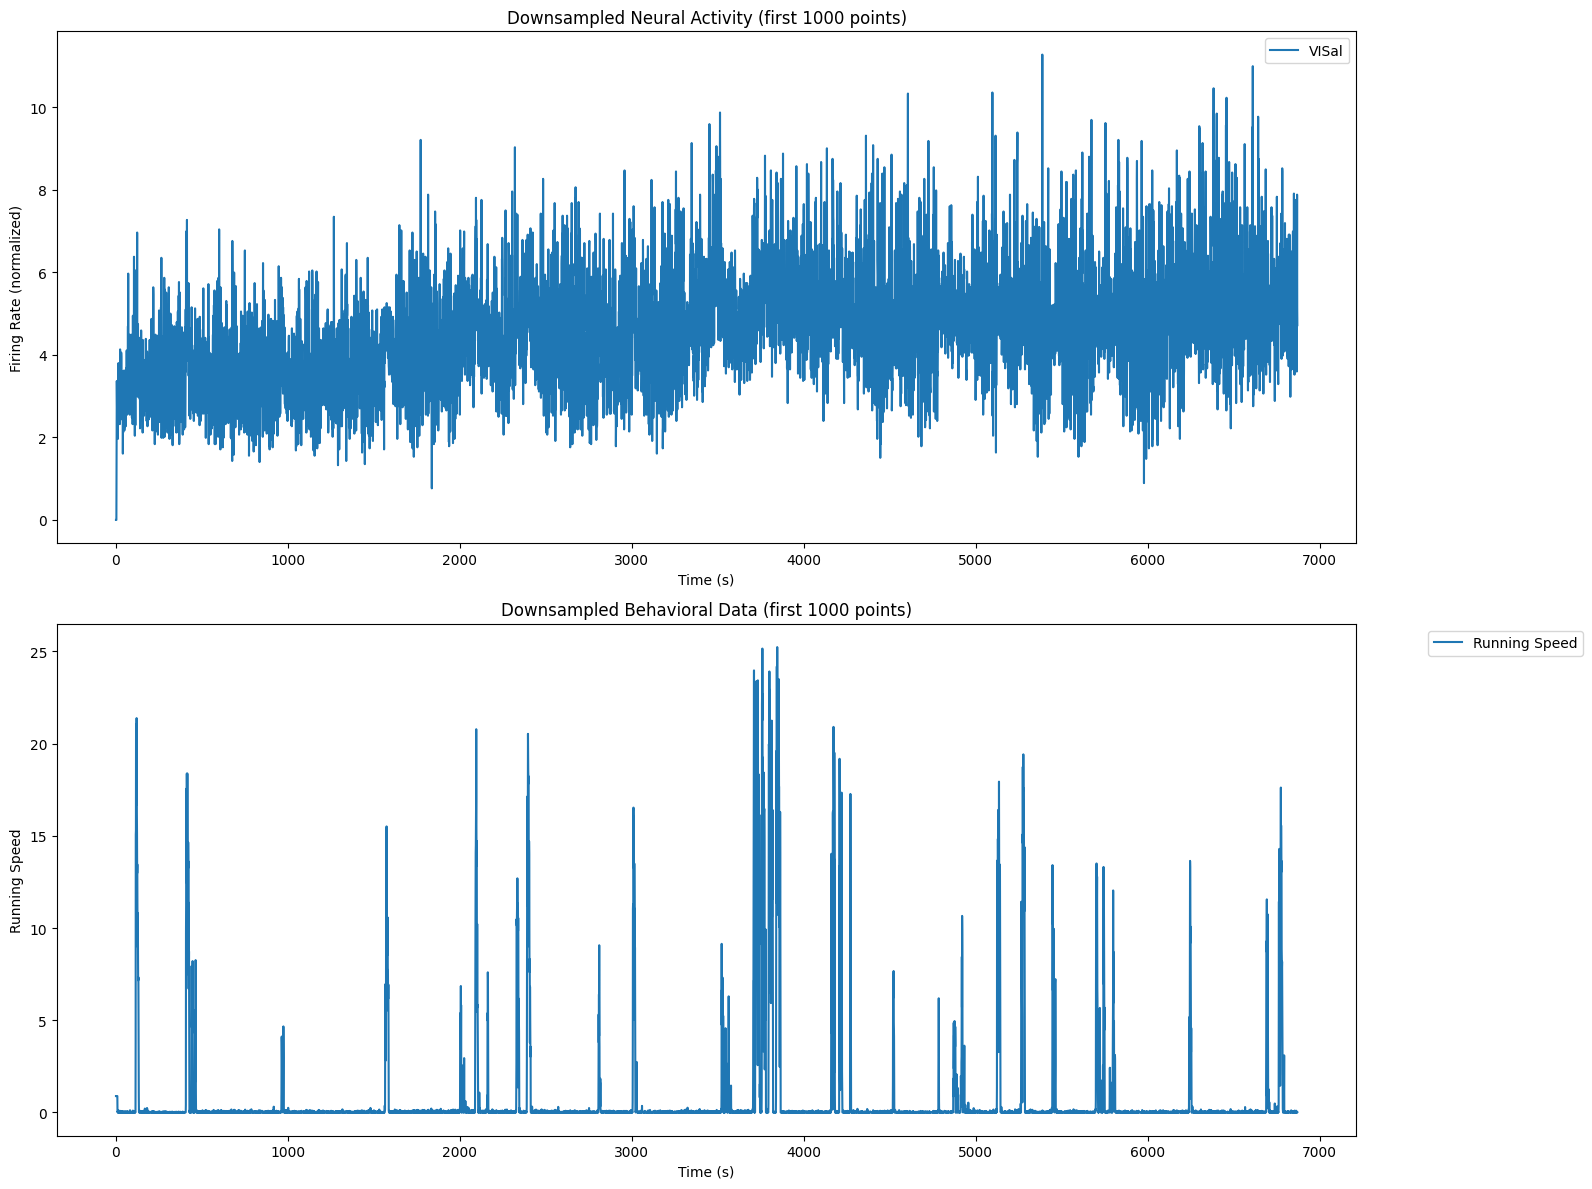

In [171]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 12))
plt.subplot(2, 1, 1)
plt.plot(t_ds_train, Y_ds_train[:,0])  # plot first 1000 points
plt.title("Downsampled Neural Activity (first 1000 points)")
plt.xlabel("Time (s)")
plt.ylabel("Firing Rate (normalized)")
plt.legend(regions)
plt.subplot(2, 1, 2)
plt.plot(t_ds_train, running_ds_train)  # plot first 1000 points
plt.title("Downsampled Behavioral Data (first 1000 points)")
plt.xlabel("Time (s)")
plt.ylabel("Running Speed")
plt.legend(['Running Speed'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [172]:
class FourierFeatures(nn.Module):
    def __init__(self, n_freq = 64, min_freq=1.0, max_freq=1000.0):
        super().__init__()
        self.n_freq = n_freq
        freqs = torch.logspace(np.log10(min_freq), np.log10(max_freq), n_freq, device=device)  # (n_freq,)
        self.register_buffer('freqs', freqs)

    def forward(self, t):
        # t: (N, 1)
        # freqs: (n_freq,)
        # Compute outer product to get (N, n_freq)
        t_proj = 2 * np.pi * t @ self.freqs.unsqueeze(0)  # type: ignore # (N, n_freq)
        return torch.cat([torch.sin(t_proj), torch.cos(t_proj)], dim=-1)  # (N, 2*n_freq)



ff = FourierFeatures(n_freq=64).to(device)
test_out = ff(t_tensor_train[:5])
print(f"FourierFeatures: {t_tensor_train[:5].shape} -> {test_out.shape}")
# Expected: torch.Size([5, 1]) -> torch.Size([5, 128])

FourierFeatures: torch.Size([5, 1]) -> torch.Size([5, 128])


In [173]:
# Cell 4: Wilson-Cowan Physics Module â€” Full E/I dynamics
#
# The WC equations per region:
#   Ï„_E Â· dE/dt = -E + Ïƒ(w_EEÂ·E - w_EIÂ·I + w_uEÂ·u + b_E)
#   Ï„_I Â· dI/dt = -I + Ïƒ(w_IEÂ·E - w_IIÂ·I + b_I)
#
# Both E and I are now dynamic â€” predicted by the internal head of TrajectoryNet.
# The physics loss will constrain BOTH dE/dt and dI/dt.
#
# Even though we never observe I directly, the physics loss creates a chain:
#   1. Data loss forces E to match observed firing rates
#   2. Physics loss forces dE/dt to be consistent with WC(E, I, u)
#   3. Physics loss ALSO forces dI/dt to be consistent with WC(E, I)
#   4. So I is constrained indirectly: it must be whatever value makes
#      the WC equations hold for the E that's already pinned to data
#
# This is the power of PINNs for unobserved variables â€” the physics
# propagates information from observed (E) to unobserved (I).

class WilsonCowanPhysics(nn.Module):
    def __init__(self, n_regions=4, n_stim=15):
        super().__init__()

        # --- Time constants ---
        # Controls how fast each population responds.
        # Initialized at 1.0 (equal speed for E and I).
        # Wrapped in softplus in forward() to guarantee positivity.
        # If tau is large â†’ slow response (low-pass filter)
        # If tau is small â†’ fast response (tracks input tightly)
        self.tau_E = nn.Parameter(torch.full((n_regions,), 1.0))
        self.tau_I = nn.Parameter(torch.full((n_regions,), 1.0))

        # --- Local connection weights ---
        # These define the E/I interaction strength within each region.
        #
        # w_EE = 5.0: Eâ†’E recurrence. Strong, because cortical excitatory
        #   neurons have dense local recurrent connections (~80% of synapses).
        #   Initialized at 5.0 because w_EE * a/4 must be > 1 for oscillations
        #   (Hopf bifurcation condition from wc-dynamics-theory analysis).
        #   5.0 * 4.0/4 = 5.0 >> 1, safely oscillatory.
        self.w_EE = nn.Parameter(torch.full((n_regions,), 5.0))

        # w_EI = 4.0: Iâ†’E inhibition. The brake pedal. Must be strong enough
        #   to prevent E from saturating, but not so strong that it kills all activity.
        #   4.0 is slightly less than w_EE â€” so E can win locally (creating bumps)
        #   but I eventually catches up (creating the downswing).
        self.w_EI = nn.Parameter(torch.full((n_regions,), 4.0))

        # w_IE = 3.0: Eâ†’I excitation. How strongly E recruits I.
        #   This is the delayed negative feedback: E fires â†’ I fires a moment later
        #   â†’ I suppresses E. The delay comes from tau_I, not from w_IE itself.
        self.w_IE = nn.Parameter(torch.full((n_regions,), 3.0))

        # w_II = 1.0: Iâ†’I self-inhibition. Weak in real cortex â€”
        #   inhibitory interneurons don't strongly suppress each other
        #   (they mostly target E cells). Keeps I from exploding but
        #   doesn't dominate the dynamics.
        self.w_II = nn.Parameter(torch.full((n_regions,), 1.0))

        # --- Stimulus drive ---
        # w_uE: (15, 4) â€” how each stimulus feature drives each region's E population.
        # Initialized small (0.1 * randn) because:
        #   - We don't know a priori which stimulus features matter for which region
        #   - Large init would dominate the WC dynamics before they can establish
        #   - The optimizer will scale these up for features that matter
        # Note: stimulus drives E only, not I. This is biologically correct:
        #   thalamic (LGN) inputs target layer 4 excitatory neurons.
        #   I neurons get stimulus info indirectly through local Eâ†’I connections (w_IE).
        self.w_uE = nn.Parameter(torch.randn(n_stim, n_regions) * 0.1)

        # --- Biases ---
        # Baseline drive when there's no stimulus and no recurrent input.
        # Initialized at 0: no baseline preference. The optimizer will learn
        # region-specific resting activity levels.
        self.b_E = nn.Parameter(torch.zeros(n_regions))
        self.b_I = nn.Parameter(torch.zeros(n_regions))

        # --- Sigmoid steepness ---
        # Controls the gain of the activation function.
        # a = 4.0: moderately steep. This matters because:
        #   - Too low (a=1): sigmoid is nearly linear â†’ no interesting nonlinear dynamics
        #   - Too high (a=10): sigmoid is nearly a step function â†’ gradients vanish
        #     at the flat parts, training dies
        #   - a=4.0: steep enough for nonlinear oscillations, smooth enough for gradients
        #   - Learnable: each region can tune its own gain
        self.a = nn.Parameter(torch.full((n_regions,), 4.0))

    def sigmoid(self, x):
        # WC sigmoid with learnable threshold: s(x + a)
        # self.a is (4,), x is (N, 4) â†’ broadcasting works
        return torch.sigmoid(self.a.unsqueeze(0) + x)

    def forward(self, E, I, u):
        # E: (N, 4) â€” excitatory activity from internal head
        # I: (N, 4) â€” inhibitory activity from internal head
        # u: (N, 15) â€” stimulus features
        # Returns: (dE/dt, dI/dt) both (N, 4)

        # Softplus guarantees tau > 0 without hard clipping
        # (hard clipping kills gradients at the boundary)
        tau_E = nn.functional.softplus(self.tau_E).unsqueeze(0)  # (1, 4)
        tau_I = nn.functional.softplus(self.tau_I).unsqueeze(0)  # (1, 4)

        # Stimulus drive: 15 features â†’ 4 regions via learned projection
        stim_drive = u @ self.w_uE  # (N, 15) @ (15, 4) â†’ (N, 4)

        # WC equations:
        # dE/dt = (-E + Ïƒ(w_EEÂ·E - w_EIÂ·I + stim + b_E)) / Ï„_E
        #   -E: decay term, pulls E back to zero (leak)
        #   Ïƒ(...): activation from recurrent + stimulus input
        #   /Ï„_E: time constant scales how fast this happens
        dEdt = (-E + self.sigmoid(self.w_EE * E - self.w_EI * I + stim_drive + self.b_E)) / tau_E

        # dI/dt = (-I + Ïƒ(w_IEÂ·E - w_IIÂ·I + b_I)) / Ï„_I
        #   Same structure but NO stimulus term â€” I is driven by local E only
        dIdt = (-I + self.sigmoid(self.w_IE * E - self.w_II * I + self.b_I)) / tau_I

        return dEdt, dIdt  # both needed for physics loss now

# Test it
wc = WilsonCowanPhysics().to(device)
test_E = torch.rand(5, 4, device=device)
test_I = torch.rand(5, 4, device=device)
test_u = torch.rand(5, 15, device=device)
test_dEdt, test_dIdt = wc(test_E, test_I, test_u)
print(f"WC physics: E{test_E.shape} + I{test_I.shape} + u{test_u.shape} -> dE/dt{test_dEdt.shape}, dI/dt{test_dIdt.shape}")

n_wc_params = sum(p.numel() for p in wc.parameters())
print(f"WC learnable parameters: {n_wc_params}")


WC physics: Etorch.Size([5, 4]) + Itorch.Size([5, 4]) + utorch.Size([5, 15]) -> dE/dttorch.Size([5, 4]), dI/dttorch.Size([5, 4])
WC learnable parameters: 96


In [174]:
# Cell 3: TrajectoryNet â€” Stim MLP + GRU Internal Head
#
# Stim head: fourier(t) + U_rich â†’ MLP â†’ stim_out (same as before, works well)
# Internal head: behavioral(t) â†’ GRU â†’ E(t), I(t)
#
# Why GRU instead of MLP for the internal head?
#   The MLP is a static function approximator: f(t, beh) â†’ E, I
#   It has no temporal memory â€” the output at time t depends only on inputs at time t.
#   The easiest function it can learn is a constant or slow drift.
#
#   A GRU processes data SEQUENTIALLY: hidden state at time t depends on
#   hidden state at t-1. It naturally learns temporal dynamics because it
#   literally carries state forward. Brain state (arousal, running epochs,
#   drowsiness) evolves over time â€” a recurrent model matches this.
#
# Combined: sigmoid(stim_out + E_int) â€” additive, same as the best-performing version.
# WC physics: constrains dE/dt and dI/dt using central differences on GRU output.

class TrajectoryNet(nn.Module):
    def __init__(self, n_fourier=128, n_stim=15, n_regions=4, n_behavioral=2,
                 hidden=128, gru_hidden=64, gru_layers=2):
        super().__init__()
        self.n_regions = n_regions
        self.gru_hidden = gru_hidden
        self.fourier = FourierFeatures(n_freq=64)

        # Stimulus head: fourier(t) + stimulus â†’ MLP â†’ 4 outputs (unchanged)
        self.stim_head = nn.Sequential(
            nn.Linear(n_fourier + n_stim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, n_regions)
        )

        # Internal head: GRU over behavioral time series
        # Input: behavioral features (running speed + pupil) at each timestep
        # GRU hidden state = brain state, evolving over time
        self.gru = nn.GRU(
            input_size=n_behavioral,    # 2: running + pupil
            hidden_size=gru_hidden,     # 64-dim hidden state
            num_layers=gru_layers,      # 2 layers for capacity
            batch_first=True,           # input shape: (1, T, 2)
            dropout=0.1                 # regularization between layers
        )

        # Project GRU hidden state to E and I per region
        self.gru_proj = nn.Sequential(
            nn.Linear(gru_hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, n_regions * 2)  # 8: 4 E + 4 I
        )

    def forward_stim(self, t, u):
        # Stim head only â€” used independently, works on arbitrary timesteps
        f = self.fourier(t)  # (N, 128)
        stim_out = self.stim_head(torch.cat([f, u], dim=-1))  # (N, 4)
        return stim_out

    def forward_internal(self, beh):
        # Internal head: run GRU over full behavioral sequence
        # beh: (T, 2) â†’ unsqueeze to (1, T, 2) for batch_first GRU
        gru_out, _ = self.gru(beh.unsqueeze(0))  # (1, T, gru_hidden)
        gru_out = gru_out.squeeze(0)              # (T, gru_hidden)

        int_out = self.gru_proj(gru_out)  # (T, 8)
        E_int = int_out[:, :self.n_regions]  # (T, 4)
        I_int = int_out[:, self.n_regions:]  # (T, 4)
        return E_int, I_int

    def forward(self, t, u, beh):
        stim_out = self.forward_stim(t, u)   # (N, 4)
        E_int, I_int = self.forward_internal(beh)  # (T, 4) each

        combined = (torch.sigmoid(stim_out) + torch.sigmoid(E_int))/2.0  # (N, 4)
        return combined, stim_out, E_int, I_int

# Test it
model = TrajectoryNet().to(device)
pred, s_out, e_out, i_out = model(t_tensor_train[:100], U_tensor_train[:100], beh_tensor_train[:100])
print(f"Combined: {pred.shape}")
print(f"Stim head: {s_out.shape}")
print(f"E_int: {e_out.shape}")
print(f"I_int: {i_out.shape}")
print(f"E_int std across time: {e_out.std(dim=0).mean():.4f}")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total TrajectoryNet parameters: {total_params:,}")

Combined: torch.Size([100, 4])
Stim head: torch.Size([100, 4])
E_int: torch.Size([100, 4])
I_int: torch.Size([100, 4])
E_int std across time: 0.0088
Total TrajectoryNet parameters: 82,828


In [175]:
# Test it
wc = WilsonCowanPhysics().to(device)
test_E = torch.rand(5, 4, device=device)
test_I = torch.rand(5, 4, device=device)
test_u = torch.rand(5, 15, device=device)
test_dEdt, test_dIdt = wc(test_E, test_I, test_u)
print(f"WC physics: E{test_E.shape} + I{test_I.shape} + u{test_u.shape} -> dE/dt{test_dEdt.shape}, dI/dt{test_dIdt.shape}")

n_wc_params = sum(p.numel() for p in wc.parameters())
print(f"WC learnable parameters: {n_wc_params}")

WC physics: Etorch.Size([5, 4]) + Itorch.Size([5, 4]) + utorch.Size([5, 15]) -> dE/dttorch.Size([5, 4]), dI/dttorch.Size([5, 4])
WC learnable parameters: 96


In [176]:
import copy

model = TrajectoryNet().to(device)
wc = WilsonCowanPhysics().to(device)

optimizer = torch.optim.Adam(
    list(model.parameters()) + list(wc.parameters()),
    lr=1e-3
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=2000, eta_min=1e-5)

n_epochs = 500
lambda_phys = 1.0
lambda_ic = 10.0
lambda_dyn = 5
dyn_floor_E = 0.2
dyn_floor_I = 0.2
ramp_epochs = 500

# dt for central differences (ds=40 bins * 0.02s per bin = 0.8s)
dt = 0.8  # seconds per downsampled timestep

losses_data = []
losses_phys = []
losses_total = []
losses_val = []

best_val_loss = float('inf')
best_epoch = -1
best_model_state = copy.deepcopy(model.state_dict())
best_wc_state = copy.deepcopy(wc.state_dict())

for epoch in range(n_epochs):
    model.train()
    wc.train()
    optimizer.zero_grad()

    # ---- Forward pass (full training sequence) ----
    combined, stim_out, E_int, I_int = model(t_tensor_train, U_tensor_train, beh_tensor_train)

    # ---- L_data ----
    loss_data = nn.functional.mse_loss(combined, Y_tensor_train)

    # ---- L_IC ----
    loss_ic = nn.functional.mse_loss(combined[0], Y_tensor_train[0])

    # ---- Central differences on latent trajectories ----
    dEdt_cd = (E_int[2:] - E_int[:-2]) / (2 * dt)   # (T-2, 4)
    dIdt_cd = (I_int[2:] - I_int[:-2]) / (2 * dt)   # (T-2, 4)

    # ---- L_dyn: penalize windows with very small average derivatives ----
    # This discourages long flat latent segments without forcing oscillations everywhere.
    window = 100
    stride = 50

    if dEdt_cd.shape[0] >= window:
        dE_win = dEdt_cd.unfold(0, window, stride)   # (n_win, 4, window)
        dI_win = dIdt_cd.unfold(0, window, stride)   # (n_win, 4, window)

        dE_win_mean = dE_win.abs().mean(dim=-1)      # (n_win, 4)
        dI_win_mean = dI_win.abs().mean(dim=-1)      # (n_win, 4)

        loss_dyn = (
            torch.mean(nn.functional.leaky_relu(dyn_floor_E - dE_win_mean, negative_slope=0.05) ** 3) +
            torch.mean(nn.functional.leaky_relu(dyn_floor_I - dI_win_mean, negative_slope=0.05) ** 3)
        )

    else:
        # Fallback if the sequence is shorter than the window
        loss_dyn = (
            torch.mean(nn.functional.leaky_relu(dyn_floor_E - dEdt_cd.abs(), negative_slope=0.05) ** 3) +
            torch.mean(nn.functional.leaky_relu(dyn_floor_I - dIdt_cd.abs(), negative_slope=0.05) ** 3)
        )


    # ---- L_phys: central difference vs Wilson-Cowan ----
    # lambda_phys = min(lambda_phys_max * epoch / ramp_epochs, lambda_phys_max)

    if lambda_phys > 0:
        # Corresponding E, I, U at interior points
        E_mid = torch.sigmoid(E_int[1:-1])   # (T-2, 4)
        I_mid = torch.sigmoid(I_int[1:-1])   # (T-2, 4)
        U_mid = U_tensor_train[1:-1]         # (T-2, 15)

        # Wilson-Cowan predicted derivatives
        dEdt_wc, dIdt_wc = wc(E_mid, I_mid, U_mid)

        # Random subset for memory efficiency
        n_phys = min(2000, dEdt_cd.shape[0])
        idx = torch.randint(0, dEdt_cd.shape[0], (n_phys,), device=device)

        loss_phys = (
            nn.functional.mse_loss(dEdt_cd[idx], dEdt_wc[idx]) +
            nn.functional.mse_loss(dIdt_cd[idx], dIdt_wc[idx])
        )
    else:
        loss_phys = torch.tensor(0.0, device=device)

    # ---- Total loss ----
    loss = loss_data + lambda_ic * loss_ic + lambda_phys * loss_phys + lambda_dyn * loss_dyn

    loss.backward()
    torch.nn.utils.clip_grad_norm_(
        list(model.parameters()) + list(wc.parameters()),
        max_norm=1.0
    )
    optimizer.step()
    scheduler.step()

    model.eval()
    wc.eval()
    with torch.no_grad():
        combined_val, _, _, _ = model(t_tensor_val, U_tensor_val, beh_tensor_val)
        val_loss = nn.functional.mse_loss(combined_val, Y_tensor_val)

    if val_loss.item() < best_val_loss and epoch >= 10:  # allow some warmup epochs
        best_val_loss = val_loss.item()
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        best_wc_state = copy.deepcopy(wc.state_dict())

    losses_data.append(loss_data.item())
    losses_phys.append(loss_phys.item())
    losses_total.append(loss.item())
    losses_val.append(val_loss.item())

    if epoch % 25 == 0 or epoch == n_epochs - 1:
        lr_now = scheduler.get_last_lr()[0]
        phys_val = loss_phys.item()
        dyn_val = loss_dyn.item()
        e_std_mean = E_int.std(dim=0).mean().item()
        i_std_mean = I_int.std(dim=0).mean().item()
        dE_mag = dEdt_cd.abs().mean().item()
        dI_mag = dIdt_cd.abs().mean().item()
        print(
            f"Epoch {epoch:4d} | Total Loss: {loss.item():.6f} | "
            f"data: {loss_data.item():.6f} | "
            f"val: {val_loss.item():.6f} | "
            f"phys: {phys_val:.6f} | "
            f"dyn: {dyn_val:.6f} | "
            f"|dE/dt|: {dE_mag:.6f} | |dI/dt|: {dI_mag:.6f} | "
            f"E_std: {e_std_mean:.4f} | I_std: {i_std_mean:.4f} | "
            f"λ_phys: {lambda_phys:.3f} | lr: {lr_now:.6f}"
        )

# print(f"\nTraining complete. Best val epoch: {best_epoch} | Best val MSE: {best_val_loss:.6f}")



Epoch    0 | Total Loss: 3.038554 | data: 0.035816 | val: 0.022017 | phys: 0.270980 | dyn: 0.015250 | |dE/dt|: 0.003158 | |dI/dt|: 0.003199 | E_std: 0.0160 | I_std: 0.0164 | λ_phys: 1.000 | lr: 0.001000
Epoch   25 | Total Loss: 0.348428 | data: 0.045436 | val: 0.059654 | phys: 0.104850 | dyn: 0.005781 | |dE/dt|: 0.081020 | |dI/dt|: 0.043204 | E_std: 0.5593 | I_std: 0.3098 | λ_phys: 1.000 | lr: 0.001000
Epoch   50 | Total Loss: 0.118275 | data: 0.057086 | val: 0.045566 | phys: 0.037264 | dyn: 0.004436 | |dE/dt|: 0.089837 | |dI/dt|: 0.055360 | E_std: 0.2203 | I_std: 0.1129 | λ_phys: 1.000 | lr: 0.000998
Epoch   75 | Total Loss: 0.092223 | data: 0.040155 | val: 0.037800 | phys: 0.031190 | dyn: 0.004041 | |dE/dt|: 0.080747 | |dI/dt|: 0.068366 | E_std: 0.2196 | I_std: 0.1377 | λ_phys: 1.000 | lr: 0.000996
Epoch  100 | Total Loss: 0.074070 | data: 0.027140 | val: 0.035928 | phys: 0.026551 | dyn: 0.003960 | |dE/dt|: 0.076838 | |dI/dt|: 0.073970 | E_std: 0.2247 | I_std: 0.1481 | λ_phys: 1.000 

=== R² Scores ===
Region       Combined  Stim Only Internal E
---------------------------------------------
VISal          0.0641   -10.2718   -16.3534
VISl          -0.0731   -14.3665   -20.7446
VISp          -0.1937    -6.9268   -14.9816
VISpm         -0.1810    -5.6397   -13.8078

Train MSE: 0.015193
Val MSE:   0.039077


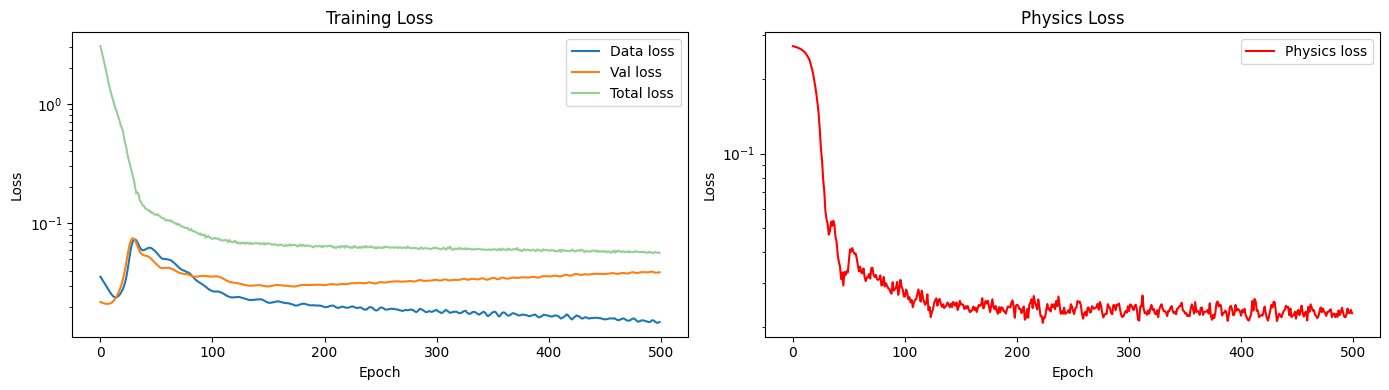

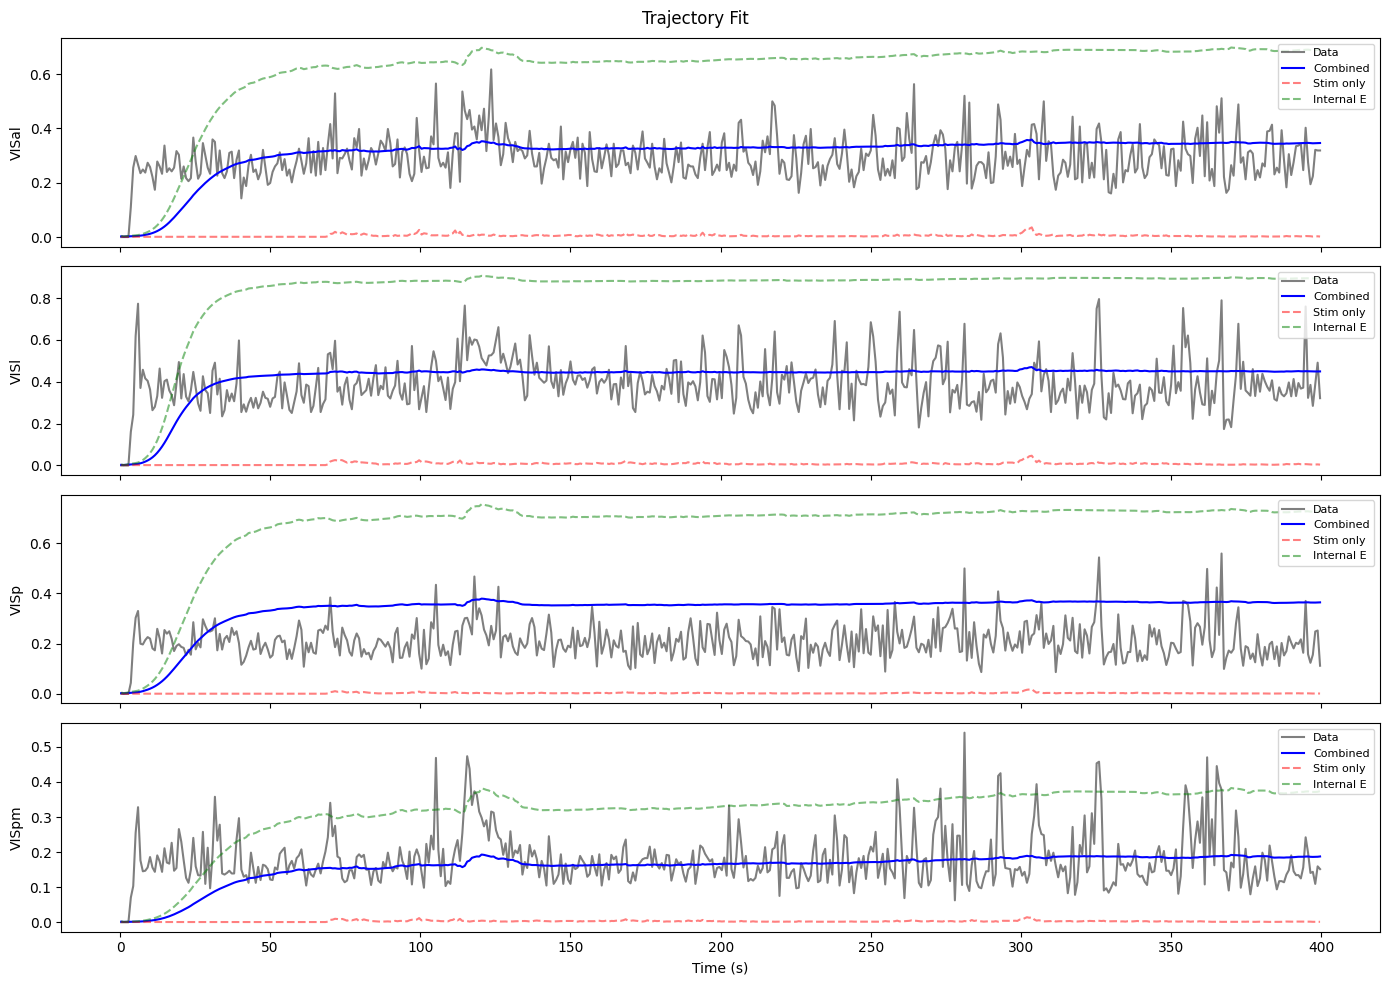

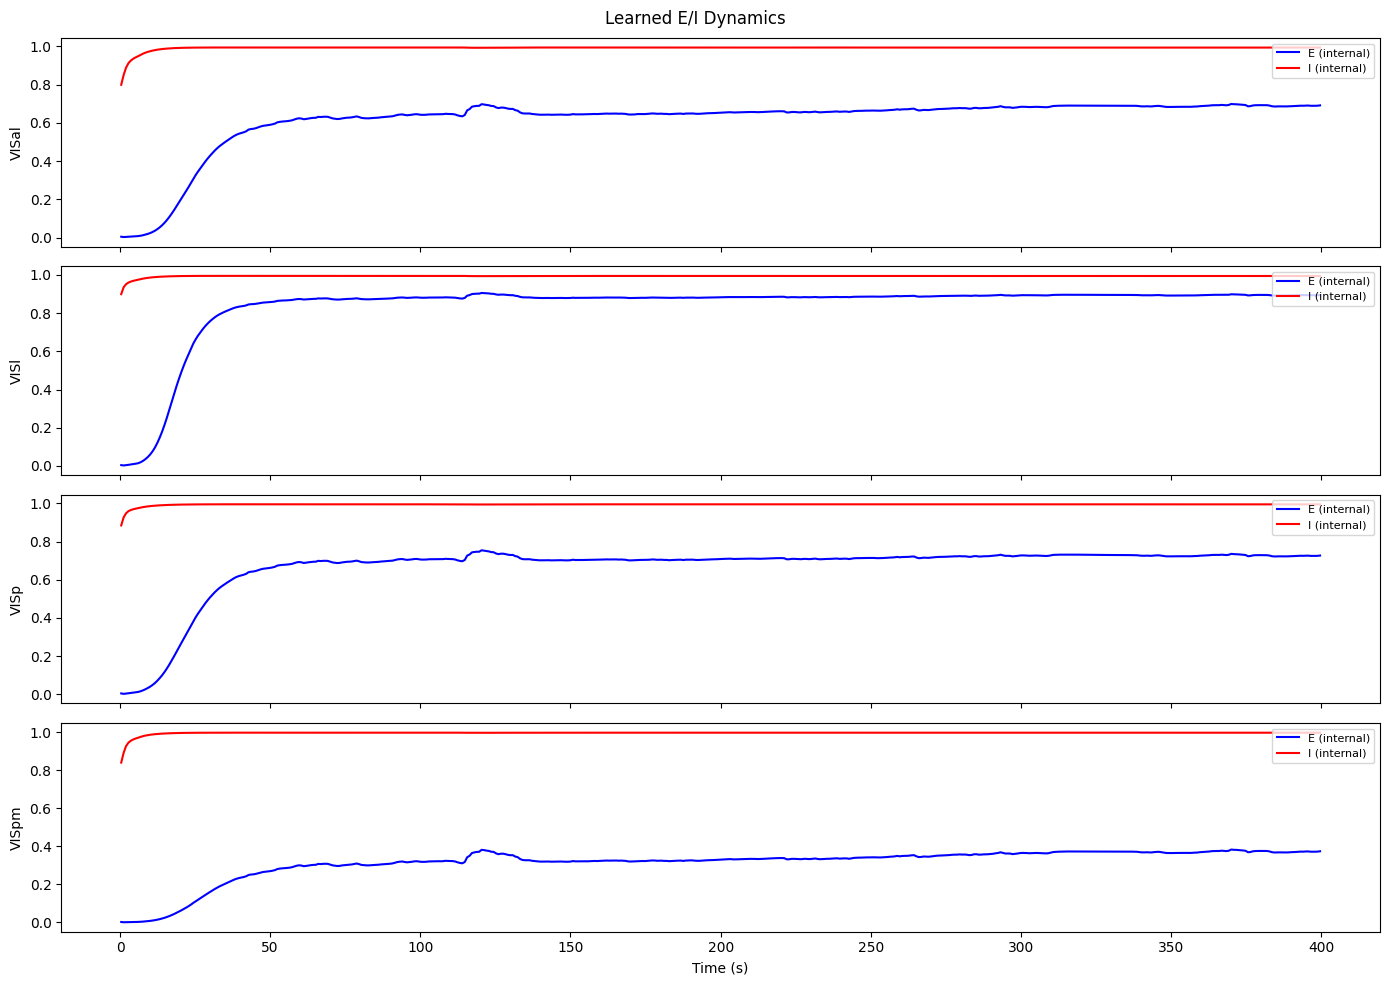

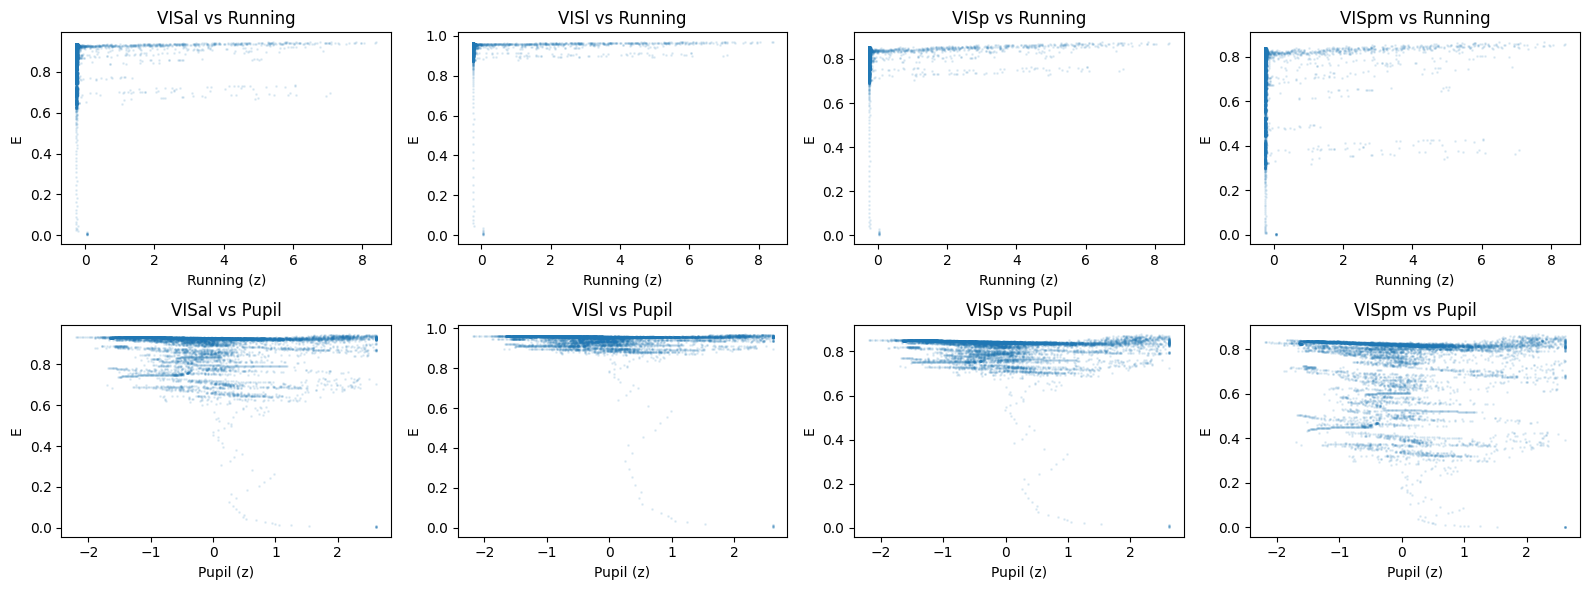


=== Learned WC Parameters ===
tau_E: [1.3784761 1.3582994 1.4202423 1.4336214]
tau_I: [1.3395712 1.3382336 1.3406936 1.3389772]
w_EE:  [4.7199755 4.8513393 4.632555  4.602783 ]
w_EI:  [4.243131  4.106567  4.3241186 4.3389997]
w_IE:  [2.9200156 2.921234  2.9216254 2.9424517]
w_II:  [1.048404  1.0455129 1.0496169 1.0201683]
a:     [3.8214145 3.9118216 3.7458296 3.7220757]
b_E:   [-0.19982563 -0.09292962 -0.2786092  -0.2969119 ]
b_I:   [-0.04322499 -0.04142723 -0.04475141 -0.02463236]

=== E/I Dynamics Statistics ===
I_int std per region:  [0.00339717 0.00200491 0.00193761 0.00246827]
E_int range per region: [0.00235592 0.00238937 0.00282457 0.00113726] to [0.946969   0.96935946 0.87706715 0.8666743 ]


In [177]:
# Cell 6: Evaluation & Plots

model.eval()
wc.eval()
with torch.no_grad():
    combined, stim_out, E_int, I_int = model(t_tensor_train, U_tensor_train, beh_tensor_train)
    combined_val, _, _, _ = model(t_tensor_val, U_tensor_val, beh_tensor_val)
    pred = combined.cpu().numpy()
    stim_pred = torch.sigmoid(stim_out).cpu().numpy()
    E_pred = torch.sigmoid(E_int).cpu().numpy()
    I_pred = torch.sigmoid(I_int).cpu().numpy()
    Y_np = Y_tensor_train.cpu().numpy()


def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

print("=== R² Scores ===")
print(f"{'Region':<10} {'Combined':>10} {'Stim Only':>10} {'Internal E':>10}")
print("-" * 45)
for i, reg in enumerate(regions):
    r2_comb = r_squared(Y_np[:, i], pred[:, i])
    r2_stim = r_squared(Y_np[:, i], stim_pred[:, i])
    r2_int  = r_squared(Y_np[:, i], E_pred[:, i])
    print(f"{reg:<10} {r2_comb:>10.4f} {r2_stim:>10.4f} {r2_int:>10.4f}")

train_loss = nn.functional.mse_loss(combined, Y_tensor_train).item()
val_loss = nn.functional.mse_loss(combined_val, Y_tensor_val).item()
print(f"\nTrain MSE: {train_loss:.6f}")
print(f"Val MSE:   {val_loss:.6f}")

# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].semilogy(losses_data, label='Data loss')
axes[0].semilogy(losses_val, label='Val loss')
axes[0].semilogy(losses_total, label='Total loss', alpha=0.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].set_title('Training Loss')
axes[1].semilogy(losses_phys, label='Physics loss', color='red')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].set_title('Physics Loss')
plt.tight_layout(); plt.show()

# Trajectory overlay
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
t_plot = t_ds_train[:500]
for i, reg in enumerate(regions):
    axes[i].plot(t_plot, Y_np[:500, i], 'k', alpha=0.5, label='Data')
    axes[i].plot(t_plot, pred[:500, i], 'b', label='Combined')
    axes[i].plot(t_plot, stim_pred[:500, i], 'r--', alpha=0.5, label='Stim only')
    axes[i].plot(t_plot, E_pred[:500, i], 'g--', alpha=0.5, label='Internal E')
    axes[i].set_ylabel(reg); axes[i].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Trajectory Fit'); plt.tight_layout(); plt.show()

# E vs I dynamics
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i, reg in enumerate(regions):
    axes[i].plot(t_plot, E_pred[:500, i], 'b', label='E (internal)')
    axes[i].plot(t_plot, I_pred[:500, i], 'r', label='I (internal)')
    axes[i].set_ylabel(reg); axes[i].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Learned E/I Dynamics'); plt.tight_layout(); plt.show()

# E/I vs behavioral state
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
beh_np = beh_tensor_train.cpu().numpy()
for i, reg in enumerate(regions):
    axes[0, i].scatter(beh_np[:, 0], E_pred[:, i], s=1, alpha=0.1)
    axes[0, i].set_xlabel('Running (z)'); axes[0, i].set_ylabel(f'E')
    axes[0, i].set_title(f'{reg} vs Running')
    axes[1, i].scatter(beh_np[:, 1], E_pred[:, i], s=1, alpha=0.1)
    axes[1, i].set_xlabel('Pupil (z)'); axes[1, i].set_ylabel(f'E')
    axes[1, i].set_title(f'{reg} vs Pupil')
plt.tight_layout(); plt.show()

# Learned WC parameters
print("\n=== Learned WC Parameters ===")
with torch.no_grad():
    print(f"tau_E: {nn.functional.softplus(wc.tau_E).cpu().numpy()}")
    print(f"tau_I: {nn.functional.softplus(wc.tau_I).cpu().numpy()}")
    print(f"w_EE:  {wc.w_EE.cpu().numpy()}")
    print(f"w_EI:  {wc.w_EI.cpu().numpy()}")
    print(f"w_IE:  {wc.w_IE.cpu().numpy()}")
    print(f"w_II:  {wc.w_II.cpu().numpy()}")
    print(f"a:     {wc.a.cpu().numpy()}")
    print(f"b_E:   {wc.b_E.cpu().numpy()}")
    print(f"b_I:   {wc.b_I.cpu().numpy()}")

print("\n=== E/I Dynamics Statistics ===")
print(f"I_int std per region:  {I_pred.std(axis=0)}")
print(f"E_int range per region: {E_pred.min(axis=0)} to {E_pred.max(axis=0)}")



=== Test R² Scores ===
Region       Combined  Stim Only Internal E
---------------------------------------------
VISal         -0.2591    -0.6508    -0.1389
VISl          -0.8727    -0.6825    -1.5677
VISp           0.0117    -0.1990     0.0470
VISpm         -0.0586    -0.2703    -0.0276

Test MSE: 0.012639


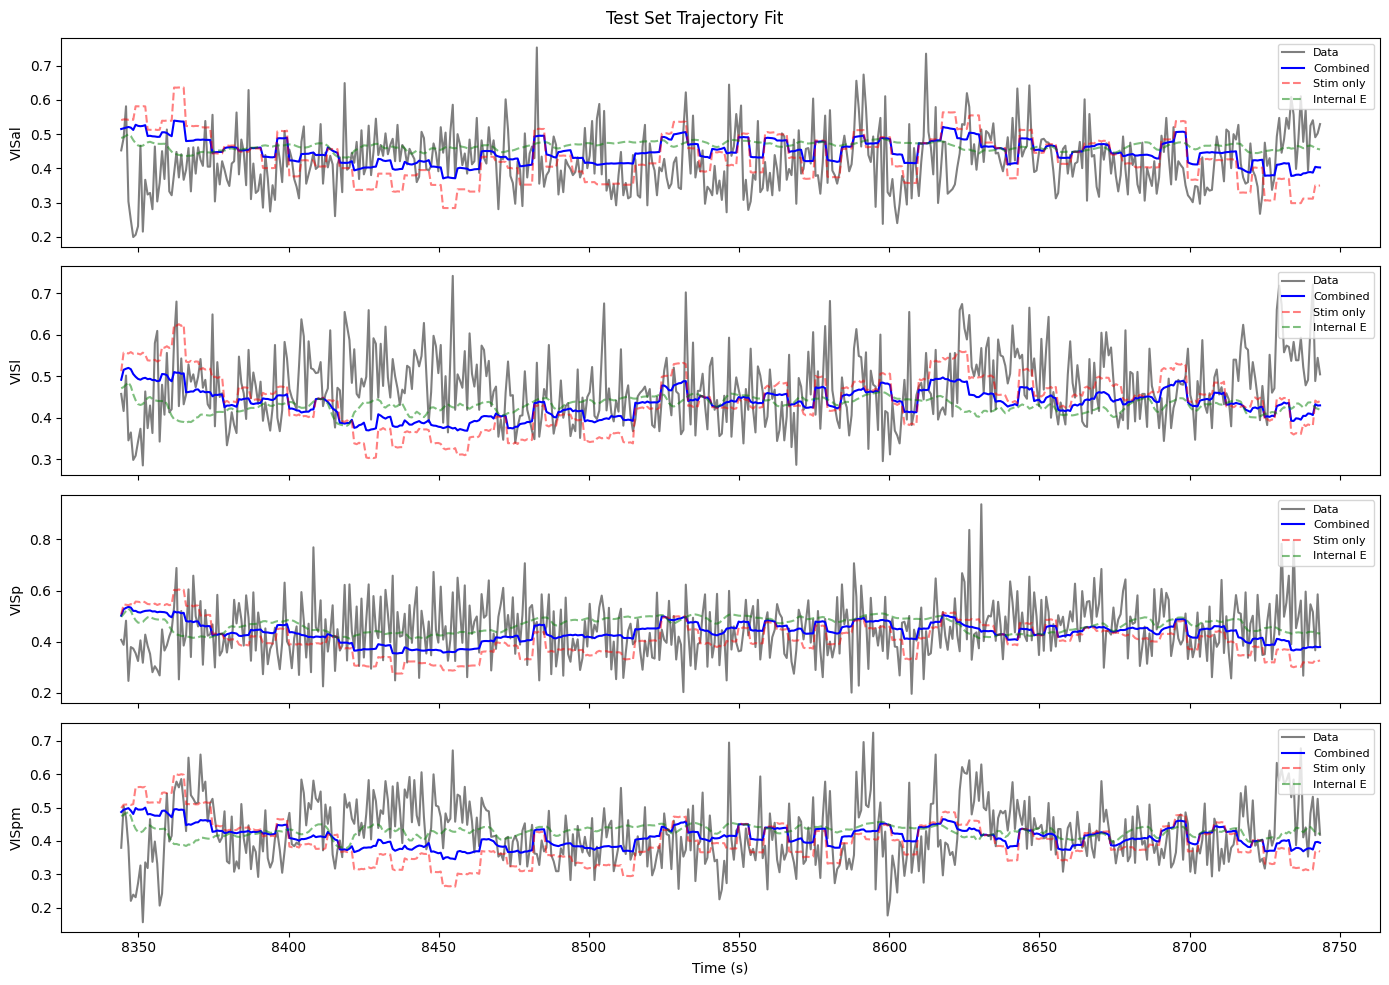

In [178]:
# Cell 7: Test Set Evaluation (uses the best-validation model loaded after training)
model.load_state_dict(best_model_state)
wc.load_state_dict(best_wc_state)
model.eval()
with torch.no_grad():
    combined_test, stim_out_test, E_int_test, I_int_test = model(t_tensor_test, U_tensor_test, beh_tensor_test)
    pred_test = combined_test.cpu().numpy()
    stim_pred_test = torch.sigmoid(stim_out_test).cpu().numpy()
    E_pred_test = torch.sigmoid(E_int_test).cpu().numpy()
    I_pred_test = torch.sigmoid(I_int_test).cpu().numpy()
    Y_test_np = Y_tensor_test.cpu().numpy()

print("=== Test R² Scores ===")
print(f"{'Region':<10} {'Combined':>10} {'Stim Only':>10} {'Internal E':>10}")
print("-" * 45)
for i, reg in enumerate(regions):
    r2_comb = r_squared(Y_test_np[:, i], pred_test[:, i])
    r2_stim = r_squared(Y_test_np[:, i], stim_pred_test[:, i])
    r2_int = r_squared(Y_test_np[:, i], E_pred_test[:, i])
    print(f"{reg:<10} {r2_comb:>10.4f} {r2_stim:>10.4f} {r2_int:>10.4f}")

test_loss = nn.functional.mse_loss(combined_test, Y_tensor_test).item()
print(f"\nTest MSE: {test_loss:.6f}")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
t_plot_test = t_ds_test[:500]
for i, reg in enumerate(regions):
    axes[i].plot(t_plot_test, Y_test_np[:500, i], 'k', alpha=0.5, label='Data')
    axes[i].plot(t_plot_test, pred_test[:500, i], 'b', label='Combined')
    axes[i].plot(t_plot_test, stim_pred_test[:500, i], 'r--', alpha=0.5, label='Stim only')
    axes[i].plot(t_plot_test, E_pred_test[:500, i], 'g--', alpha=0.5, label='Internal E')
    axes[i].set_ylabel(reg)
    axes[i].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Test Set Trajectory Fit')
plt.tight_layout()
plt.show()

